<a href="https://colab.research.google.com/github/filipecalegario/intro-programacao-python/blob/main/11_Dados_Visualizacao/Exercicios_Pandas_Visualizacao_preenchido.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔧 Exercícios Práticos de Pandas e Visualização de Dados — preenchido
## Módulo de Introdução a Python — Residência em Software Automotivo (Calibração)

> ⚠️ **Este notebook contém as respostas dos exercícios.** Use para conferência e consulta rápida.

---


---
# Parte 1 — Pandas: Series


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


## Exercício 1 — Criando Series a partir de dados de sensores

Um sensor de temperatura do motor registrou leituras (°C) ao longo de 6 instantes.

**Tarefas:**
1. Crie uma `Series` chamada `temp_motor` com esses dados, usando os instantes como índice.
2. Imprima a temperatura no instante `t3`.
3. Calcule e imprima a temperatura média, mínima e máxima.


In [2]:
# Exercício 1 — Resolução
temp_motor = pd.Series(
    [85.2, 87.5, 91.0, 93.8, 89.4, 86.1],
    index=['t0', 't1', 't2', 't3', 't4', 't5']
)
print("Series completa:")
print(temp_motor)

print(f"\nTemperatura em t3: {temp_motor['t3']} °C")

print(f"\nMédia: {temp_motor.mean():.2f} °C")
print(f"Mínima: {temp_motor.min()} °C")
print(f"Máxima: {temp_motor.max()} °C")


Series completa:
t0    85.2
t1    87.5
t2    91.0
t3    93.8
t4    89.4
t5    86.1
dtype: float64

Temperatura em t3: 93.8 °C

Média: 88.83 °C
Mínima: 85.2 °C
Máxima: 93.8 °C


<Axes: >

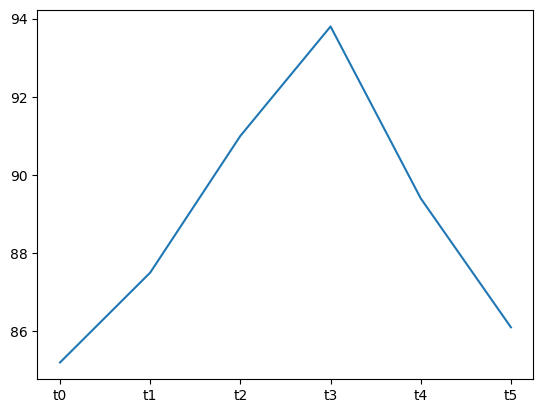

In [3]:
temp_motor.plot()

## Exercício 2 — Operações vetorizadas com Series

Dois sensores mediram o consumo de combustível (litros/100km) em 5 condições de teste.

**Tarefas:**
1. Crie duas `Series` chamadas `sensor_a` e `sensor_b`.
2. Calcule a média entre os dois sensores.
3. Calcule a diferença absoluta.
4. Identifique em qual condição a diferença é maior.


In [6]:
# Exercício 2 — Resolução
indices = ['urbano', 'estrada', 'misto', 'esportivo', 'eco']

sensor_a = pd.Series([8.5, 9.2, 7.8, 10.1, 8.9], index=indices)
sensor_b = pd.Series([8.7, 9.0, 8.0, 9.8, 9.1], index=indices)

# Média entre sensores
media_sensores = (sensor_a + sensor_b) / 2
print("Média entre sensores:")
print(media_sensores)

# Diferença absoluta
diferenca = (sensor_a - sensor_b)
print("\nDiferença:")
print(diferenca)

# Condição com maior diferença
print(f"\nMaior diferença: condição '{diferenca.idxmax()}' com {diferenca.max()} L/100km")


Média entre sensores:
urbano       8.60
estrada      9.10
misto        7.90
esportivo    9.95
eco          9.00
dtype: float64

Diferença:
urbano      -0.2
estrada      0.2
misto       -0.2
esportivo    0.3
eco         -0.2
dtype: float64

Maior diferença: condição 'esportivo' com 0.29999999999999893 L/100km


## Exercício 3 — Filtrando Series

Registro de RPM do motor em diferentes momentos de um teste.


In [8]:
rpm = pd.Series(
    [800, 1200, 2500, 3500, 4200, 5800, 6200, 3000, 1500, 900],
    index=[f'leitura_{i+1}' for i in range(10)]
)
print(rpm)


leitura_1      800
leitura_2     1200
leitura_3     2500
leitura_4     3500
leitura_5     4200
leitura_6     5800
leitura_7     6200
leitura_8     3000
leitura_9     1500
leitura_10     900
dtype: int64


In [14]:
# Exercício 3 — Resolução

# 1. RPM maior que 3000
print("RPM > 3000:")
print(rpm[rpm > 3000])

# 2. RPM entre 1500 e 4000 (inclusive)
print("\nRPM entre 1500 e 4000:")
faixa = rpm[(rpm >= 1500) & (rpm <= 4000)]
print(faixa)

# 3. Quantas leituras acima de 5000
acima_5000 = (rpm > 5000).sum()
print(f"\nLeituras acima de 5000 RPM (zona de alerta): {acima_5000}")


RPM > 3000:
leitura_4    3500
leitura_5    4200
leitura_6    5800
leitura_7    6200
dtype: int64

RPM entre 1500 e 4000:
leitura_3    2500
leitura_4    3500
leitura_8    3000
leitura_9    1500
dtype: int64

Leituras acima de 5000 RPM (zona de alerta): 2


In [15]:
rpm > 5000

,0
leitura_1,False
leitura_2,False
leitura_3,False
leitura_4,False
leitura_5,False
leitura_6,True
leitura_7,True
leitura_8,False
leitura_9,False
leitura_10,False


---
# Parte 2 — Pandas: DataFrames


## Exercício 4 — Criando DataFrames com dados de calibração


In [16]:
# Exercício 4 — Resolução
df_motor = pd.DataFrame({
    'RPM':            [1000, 2000, 3000, 4000, 5000, 6000, 6500],
    'Torque (Nm)':    [85,   145,  190,  210,  205,  185,  170],
    'Potência (kW)':  [8.9,  30.4, 59.7, 88.0, 107.3,116.2,115.7],
    'Temp. Óleo (°C)':[78,   82,   88,   95,   102,  110,  115],
    'Consumo (L/h)':  [2.1,  4.5,  7.2,  10.8, 14.1, 18.5, 21.3]
}, index=['T01','T02','T03','T04','T05','T06','T07'])

print("3 primeiras linhas:")
print(df_motor.head(3))

print("\nEstatísticas descritivas:")
print(df_motor.describe())

print("\nRPM e Potência:")
print(df_motor[['RPM', 'Potência (kW)']])


3 primeiras linhas:
      RPM  Torque (Nm)  Potência (kW)  Temp. Óleo (°C)  Consumo (L/h)
T01  1000           85            8.9               78            2.1
T02  2000          145           30.4               82            4.5
T03  3000          190           59.7               88            7.2

Estatísticas descritivas:
               RPM  Torque (Nm)  Potência (kW)  Temp. Óleo (°C)  Consumo (L/h)
count     7.000000     7.000000       7.000000         7.000000       7.000000
mean   3928.571429   170.000000      75.171429        95.714286      11.214286
std    2049.970964    43.397389      43.124769        14.008501       7.159709
min    1000.000000    85.000000       8.900000        78.000000       2.100000
25%    2500.000000   157.500000      45.050000        85.000000       5.850000
50%    4000.000000   185.000000      88.000000        95.000000      10.800000
75%    5500.000000   197.500000     111.500000       106.000000      16.300000
max    6500.000000   210.000000     116.2

<Axes: >

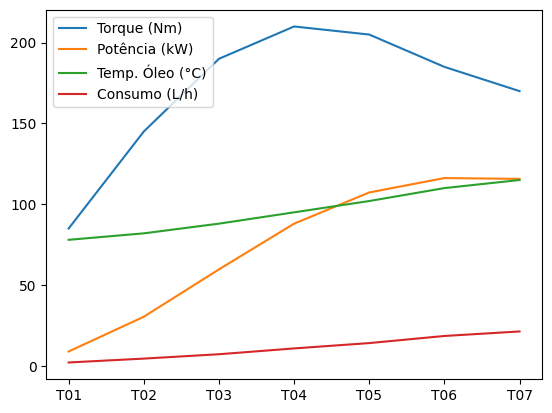

In [18]:
df_selecionado = df_motor.drop(columns=['RPM'])
df_selecionado.plot()

<Axes: >

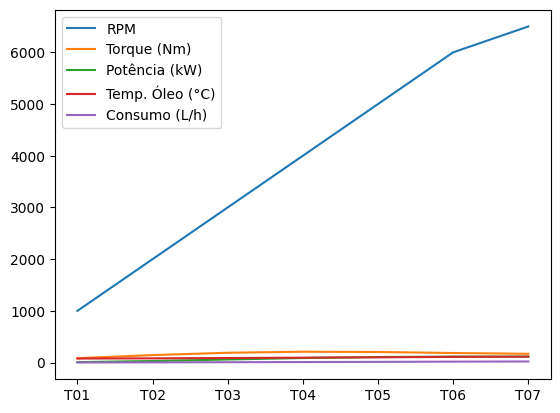

In [19]:
df_motor.plot()

## Exercício 5 — Lendo e explorando dados de um CSV


In [20]:
# Criando o CSV de exemplo
np.random.seed(42)
n = 200
datas = pd.date_range('2024-01-01', periods=n, freq='h')
dados = {
    'timestamp': datas,
    'velocidade_kmh': np.clip(np.random.normal(60, 25, n), 0, 180).round(1),
    'rpm': np.clip(np.random.normal(2500, 800, n), 700, 7000).astype(int),
    'temp_motor_c': np.clip(np.random.normal(90, 8, n), 60, 130).round(1),
    'consumo_instantaneo_lh': np.clip(np.random.normal(6, 2.5, n), 0.5, 20).round(2),
    'pressao_oleo_bar': np.clip(np.random.normal(3.5, 0.8, n), 1.0, 6.0).round(2),
    'nivel_emissao_co2_gkm': np.clip(np.random.normal(120, 30, n), 50, 250).round(1),
    'marcha': np.random.choice([1, 2, 3, 4, 5, 6], n, p=[0.05, 0.1, 0.15, 0.25, 0.3, 0.15])
}
df_sensores = pd.DataFrame(dados)
df_sensores.to_csv('sensores_veiculo.csv', index=False)
print("Arquivo 'sensores_veiculo.csv' criado com", n, "registros!")


Arquivo 'sensores_veiculo.csv' criado com 200 registros!


In [35]:
# Exercício 5 — Resolução
df = pd.read_csv('sensores_veiculo.csv', parse_dates=['timestamp'])

print("Shape:", df.shape)
print("\nTipos de dados:")
print(df.dtypes)
print("\nInfo:")
df.info()
print("\nDescrição estatística:")
print(df.describe())
print("\n10 primeiras linhas:")
df.head(10)


Shape: (200, 8)

Tipos de dados:
timestamp                 datetime64[ns]
velocidade_kmh                   float64
rpm                                int64
temp_motor_c                     float64
consumo_instantaneo_lh           float64
pressao_oleo_bar                 float64
nivel_emissao_co2_gkm            float64
marcha                             int64
dtype: object

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   timestamp               200 non-null    datetime64[ns]
 1   velocidade_kmh          200 non-null    float64       
 2   rpm                     200 non-null    int64         
 3   temp_motor_c            200 non-null    float64       
 4   consumo_instantaneo_lh  200 non-null    float64       
 5   pressao_oleo_bar        200 non-null    float64       
 6   nivel_emissao_co2_gkm   200 n

,timestamp,velocidade_kmh,rpm,temp_motor_c,consumo_instantaneo_lh,pressao_oleo_bar,nivel_emissao_co2_gkm,marcha
0,2024-01-01 00:00:00,72.4,2786,77.2,7.89,4.25,162.0,1
1,2024-01-01 01:00:00,56.5,2948,85.2,3.69,3.09,147.7,5
2,2024-01-01 02:00:00,76.2,3366,90.0,8.17,3.58,121.8,6
3,2024-01-01 03:00:00,98.1,3343,90.4,9.39,3.13,100.6,5
4,2024-01-01 04:00:00,54.1,1397,86.4,7.03,3.15,140.9,5
5,2024-01-01 05:00:00,54.1,1749,95.0,10.69,3.25,131.8,6
6,2024-01-01 06:00:00,99.5,2912,81.5,4.07,3.68,146.9,3
7,2024-01-01 07:00:00,79.2,2911,88.9,2.89,3.12,139.1,3
8,2024-01-01 08:00:00,48.3,2912,91.0,1.55,4.50,151.5,5
9,2024-01-01 09:00:00,73.6,5582,94.1,9.74,2.78,103.9,4


In [27]:
df

,velocidade_kmh,rpm,temp_motor_c,consumo_instantaneo_lh,pressao_oleo_bar,nivel_emissao_co2_gkm,marcha
timestamp,,,,,,,
2024-01-01 00:00:00,72.4,2786,77.2,7.89,4.25,162.0,1
2024-01-01 01:00:00,56.5,2948,85.2,3.69,3.09,147.7,5
2024-01-01 02:00:00,76.2,3366,90.0,8.17,3.58,121.8,6
2024-01-01 03:00:00,98.1,3343,90.4,9.39,3.13,100.6,5
2024-01-01 04:00:00,54.1,1397,86.4,7.03,3.15,140.9,5
...,...,...,...,...,...,...,...
2024-01-09 03:00:00,69.6,2124,85.9,8.63,3.28,133.2,1
2024-01-09 04:00:00,37.9,1129,87.8,5.90,4.94,119.4,4
2024-01-09 05:00:00,63.8,3583,82.2,7.70,4.01,136.6,4


<Axes: xlabel='timestamp'>

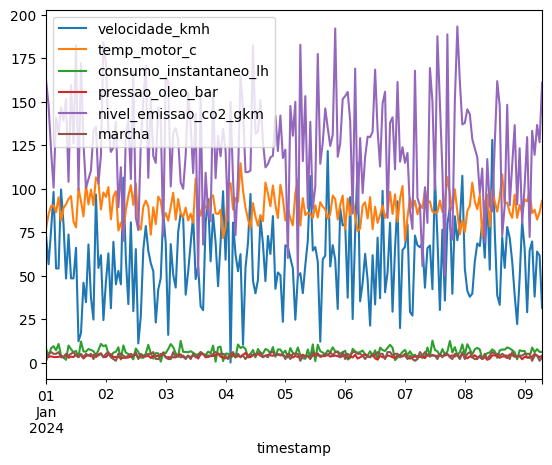

In [34]:
df.plot()

## Exercício 6 — Seleção, filtragem e criação de colunas


In [37]:
# Exercício 6 — Resolução

# 1. Selecionar colunas
print("=== Colunas selecionadas ===")
print(df[['velocidade_kmh', 'rpm', 'consumo_instantaneo_lh']].head())

# 2. Superaquecimento (temp > 100)
superaquecimento = df[df['temp_motor_c'] > 100]
print(f"\n=== Registros com superaquecimento (temp > 100°C): {len(superaquecimento)} ===")
print(superaquecimento.head())

# 3. Filtro combinado: velocidade 80-120 e rpm < 3000
filtro_combinado = df[(df['velocidade_kmh'] >= 80) & (df['velocidade_kmh'] <= 120) & (df['rpm'] < 3000)]
print(f"\n=== Velocidade 80-120 km/h e RPM < 3000: {len(filtro_combinado)} registros ===")
print(filtro_combinado.head())

# 4. Coluna de eficiência
df['eficiencia'] = (df['velocidade_kmh'] / df['consumo_instantaneo_lh']).round(2)
print("\n=== Eficiência (km/h por L/h) ===")
print(df[['velocidade_kmh', 'consumo_instantaneo_lh', 'eficiencia']].head())

# 5. Faixa de velocidade
df['faixa_velocidade'] = pd.cut(
    df['velocidade_kmh'],
    bins=[0, 40, 100, 200],
    labels=['Baixa', 'Média', 'Alta'],
    include_lowest=True
)
print("\n=== Contagem por faixa de velocidade ===")
print(df['faixa_velocidade'].value_counts())


=== Colunas selecionadas ===
   velocidade_kmh   rpm  consumo_instantaneo_lh
0            72.4  2786                    7.89
1            56.5  2948                    3.69
2            76.2  3366                    8.17
3            98.1  3343                    9.39
4            54.1  1397                    7.03

=== Registros com superaquecimento (temp > 100°C): 19 ===
             timestamp  velocidade_kmh   rpm  temp_motor_c  \
13 2024-01-01 13:00:00            12.2  3021         100.2   
16 2024-01-01 16:00:00            34.7  1881         102.4   
20 2024-01-01 20:00:00            96.6  4351         106.5   
21 2024-01-01 21:00:00            54.4  1006         104.0   
25 2024-01-02 01:00:00            62.8  3371         100.9   

    consumo_instantaneo_lh  pressao_oleo_bar  nivel_emissao_co2_gkm  marcha  \
13                    3.19              3.66                   99.3       3   
16                    6.27              3.71                  100.5       5   
20            

In [38]:
# 5. Faixa de velocidade
df['faixa_velocidade'] = pd.cut(
    df['velocidade_kmh'],
    bins=[0, 40, 100, 200],
    labels=['Baixa', 'Média', 'Alta'],
    include_lowest=True
)
print("\n=== Contagem por faixa de velocidade ===")
print(df['faixa_velocidade'].value_counts())


=== Contagem por faixa de velocidade ===
faixa_velocidade
Média    147
Baixa     46
Alta       7
Name: count, dtype: int64


In [46]:
df['faixa_velocidade'].value_counts()

,count
faixa_velocidade,
Média,147
Baixa,46
Alta,7


<Axes: title={'center': 'Distribuição por Faixa de Velocidade'}, xlabel='faixa_velocidade'>

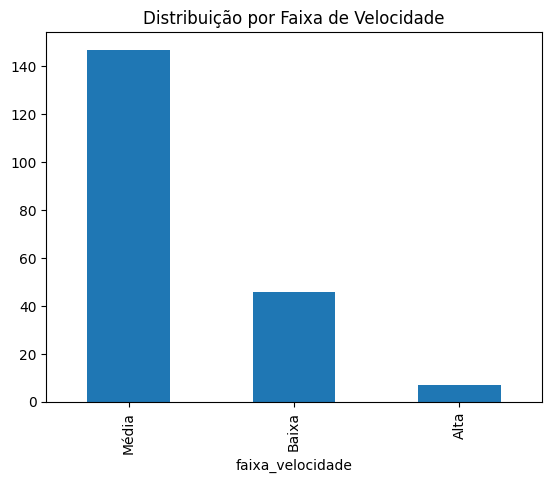

In [45]:
df['faixa_velocidade'].value_counts().plot(kind='bar', title='Distribuição por Faixa de Velocidade')

## Exercício 7 — GroupBy: agregações por grupo


In [ ]:
# Exercício 7 — Resolução

# 1. Velocidade média por marcha
print("=== Velocidade média por marcha ===")
print(df.groupby('marcha')['velocidade_kmh'].mean().round(2))

# 2. Consumo médio e máximo por marcha
print("\n=== Consumo médio e máximo por marcha ===")
print(df.groupby('marcha')['consumo_instantaneo_lh'].agg(['mean', 'max']).round(2))

# 3. Contagem por marcha
print("\n=== Registros por marcha ===")
print(df.groupby('marcha').size())

# 4. RPM médio e temp média por marcha
print("\n=== RPM médio e Temp média por marcha ===")
print(df.groupby('marcha')[['rpm', 'temp_motor_c']].mean().round(2))

# 5. Desafio: velocidade máxima por marcha
print("\n=== Velocidade máxima por marcha ===")
print(df.groupby('marcha')['velocidade_kmh'].max())


In [52]:
df.groupby('marcha')['velocidade_kmh'].mean().round(2)

,velocidade_kmh
marcha,
1,62.15
2,59.57
3,54.47
4,59.54
5,57.33
6,63.92


In [53]:
df.groupby('marcha')['consumo_instantaneo_lh'].agg(['mean', 'max', 'std']).round(2)

,mean,max,std
marcha,,,
1,6.24,8.63,1.77
2,5.99,10.62,1.89
3,5.72,12.43,2.79
4,6.31,12.58,2.21
5,5.68,12.11,2.95
6,6.49,10.69,2.63


In [55]:
df.groupby('marcha').size()

/tmp/ipykernel_1431/3088700344.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('faixa_velocidade').size()


,0
faixa_velocidade,
Baixa,46
Média,147
Alta,7


In [56]:
df.groupby('marcha')[['rpm', 'temp_motor_c']].mean().round(2)

,rpm,temp_motor_c
marcha,,
1,2377.83,86.63
2,2575.00,85.96
3,2611.92,91.57
4,2569.44,89.48
5,2574.97,89.66
6,2576.07,90.36


In [57]:
df.groupby('marcha')['velocidade_kmh'].max()

,velocidade_kmh
marcha,
1,73.0
2,107.2
3,99.5
4,121.6
5,114.8
6,128.0


## Exercício 8 — Lidando com dados faltantes


In [58]:
# Introduzindo valores faltantes
df_missing = df.copy()
np.random.seed(7)
for col in ['temp_motor_c', 'pressao_oleo_bar', 'consumo_instantaneo_lh']:
    mask = np.random.random(len(df_missing)) < 0.10
    df_missing.loc[mask, col] = np.nan
print("Valores nulos por coluna:")
print(df_missing.isnull().sum())


Valores nulos por coluna:
timestamp                  0
velocidade_kmh             0
rpm                        0
temp_motor_c              21
consumo_instantaneo_lh    18
pressao_oleo_bar          21
nivel_emissao_co2_gkm      0
marcha                     0
eficiencia                 0
faixa_velocidade           0
dtype: int64


In [59]:
df_missing

,timestamp,velocidade_kmh,rpm,temp_motor_c,consumo_instantaneo_lh,pressao_oleo_bar,nivel_emissao_co2_gkm,marcha,eficiencia,faixa_velocidade
0,2024-01-01 00:00:00,72.4,2786,NaN,7.89,4.25,162.0,1,9.18,Média
1,2024-01-01 01:00:00,56.5,2948,85.2,3.69,NaN,147.7,5,15.31,Média
2,2024-01-01 02:00:00,76.2,3366,90.0,8.17,3.58,121.8,6,9.33,Média
3,2024-01-01 03:00:00,98.1,3343,90.4,9.39,3.13,100.6,5,10.45,Média
4,2024-01-01 04:00:00,54.1,1397,86.4,7.03,3.15,140.9,5,7.70,Média
...,...,...,...,...,...,...,...,...,...,...
195,2024-01-09 03:00:00,69.6,2124,85.9,8.63,3.28,133.2,1,8.06,Média
196,2024-01-09 04:00:00,37.9,1129,87.8,5.90,4.94,119.4,4,6.42,Baixa
197,2024-01-09 05:00:00,63.8,3583,82.2,NaN,4.01,136.6,4,8.29,Média
198,2024-01-09 06:00:00,61.5,2408,86.4,NaN,3.04,126.7,1,10.13,Média


In [60]:
# Exercício 8 — Resolução

# 1. Valores nulos
print("=== Valores nulos por coluna ===")
print(df_missing.isnull().sum())

# 2. Percentual de dados faltantes
print("\n=== Percentual de dados faltantes ===")
pct_missing = (df_missing.isnull().sum() / len(df_missing) * 100).round(2)
print(pct_missing)

# 3. Removendo linhas com qualquer NaN
df_drop = df_missing.dropna()
print(f"\nShape df_drop (dropna): {df_drop.shape}")

# 4. Preenchendo NaN com mediana
df_fill = df_missing.copy()
for col in ['temp_motor_c', 'pressao_oleo_bar', 'consumo_instantaneo_lh']:
    mediana = df_fill[col].median()
    df_fill[col].fillna(mediana, inplace=True)
print(f"Shape df_fill (fillna mediana): {df_fill.shape}")
print(f"Verificação NaN em df_fill: {df_fill.isnull().sum().sum()}")

# 5. Comparação
print(f"\n=== Comparação de shapes ===")
print(f"df_missing: {df_missing.shape}")
print(f"df_drop:    {df_drop.shape} (perdemos {len(df_missing) - len(df_drop)} linhas)")
print(f"df_fill:    {df_fill.shape} (mantivemos todas as linhas)")
print("\nPara dados de calibração, preencher com mediana geralmente é preferível")
print("pois cada ponto de teste é caro e não queremos descartar dados.")


=== Valores nulos por coluna ===
timestamp                  0
velocidade_kmh             0
rpm                        0
temp_motor_c              21
consumo_instantaneo_lh    18
pressao_oleo_bar          21
nivel_emissao_co2_gkm      0
marcha                     0
eficiencia                 0
faixa_velocidade           0
dtype: int64

=== Percentual de dados faltantes ===
timestamp                  0.0
velocidade_kmh             0.0
rpm                        0.0
temp_motor_c              10.5
consumo_instantaneo_lh     9.0
pressao_oleo_bar          10.5
nivel_emissao_co2_gkm      0.0
marcha                     0.0
eficiencia                 0.0
faixa_velocidade           0.0
dtype: float64

Shape df_drop (dropna): (144, 10)
Shape df_fill (fillna mediana): (200, 10)
Verificação NaN em df_fill: 0

=== Comparação de shapes ===
df_missing: (200, 10)
df_drop:    (144, 10) (perdemos 56 linhas)
df_fill:    (200, 10) (mantivemos todas as linhas)

Para dados de calibração, preencher com median

/tmp/ipykernel_1431/2180165874.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_fill[col].fillna(mediana, inplace=True)


## Exercício 9 — Merge e Join de DataFrames


In [61]:
# Tabela de especificações por marcha
specs_marcha = pd.DataFrame({
    'marcha': [1, 2, 3, 4, 5, 6],
    'relacao_transmissao': [3.78, 2.27, 1.51, 1.14, 0.87, 0.71],
    'velocidade_ideal_min': [0, 15, 30, 50, 70, 90],
    'velocidade_ideal_max': [15, 30, 50, 70, 90, 130]
})
print(specs_marcha)


   marcha  relacao_transmissao  velocidade_ideal_min  velocidade_ideal_max
0       1                 3.78                     0                    15
1       2                 2.27                    15                    30
2       3                 1.51                    30                    50
3       4                 1.14                    50                    70
4       5                 0.87                    70                    90
5       6                 0.71                    90                   130


In [62]:
# Exercício 9 — Resolução

# 1. Merge
df_merged = df.merge(specs_marcha, on='marcha', how='left')
print("Shape após merge:", df_merged.shape)
print(df_merged.head())

# 2. Coluna marcha_adequada
df_merged['marcha_adequada'] = (
    (df_merged['velocidade_kmh'] >= df_merged['velocidade_ideal_min']) &
    (df_merged['velocidade_kmh'] <= df_merged['velocidade_ideal_max'])
)
print("\nExemplos de marcha_adequada:")
print(df_merged[['velocidade_kmh', 'marcha', 'velocidade_ideal_min', 'velocidade_ideal_max', 'marcha_adequada']].head(10))

# 3. Percentual de marchas adequadas
pct_adequada = df_merged['marcha_adequada'].mean() * 100
print(f"\nPercentual de registros com marcha adequada: {pct_adequada:.1f}%")


Shape após merge: (200, 13)
            timestamp  velocidade_kmh   rpm  temp_motor_c  \
0 2024-01-01 00:00:00            72.4  2786          77.2   
1 2024-01-01 01:00:00            56.5  2948          85.2   
2 2024-01-01 02:00:00            76.2  3366          90.0   
3 2024-01-01 03:00:00            98.1  3343          90.4   
4 2024-01-01 04:00:00            54.1  1397          86.4   

   consumo_instantaneo_lh  pressao_oleo_bar  nivel_emissao_co2_gkm  marcha  \
0                    7.89              4.25                  162.0       1   
1                    3.69              3.09                  147.7       5   
2                    8.17              3.58                  121.8       6   
3                    9.39              3.13                  100.6       5   
4                    7.03              3.15                  140.9       5   

   eficiencia faixa_velocidade  relacao_transmissao  velocidade_ideal_min  \
0        9.18            Média                 3.78        

---
# Parte 3 — Visualização de Dados


In [63]:
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
%matplotlib inline


## Exercício 10 — Gráficos de linha com Matplotlib


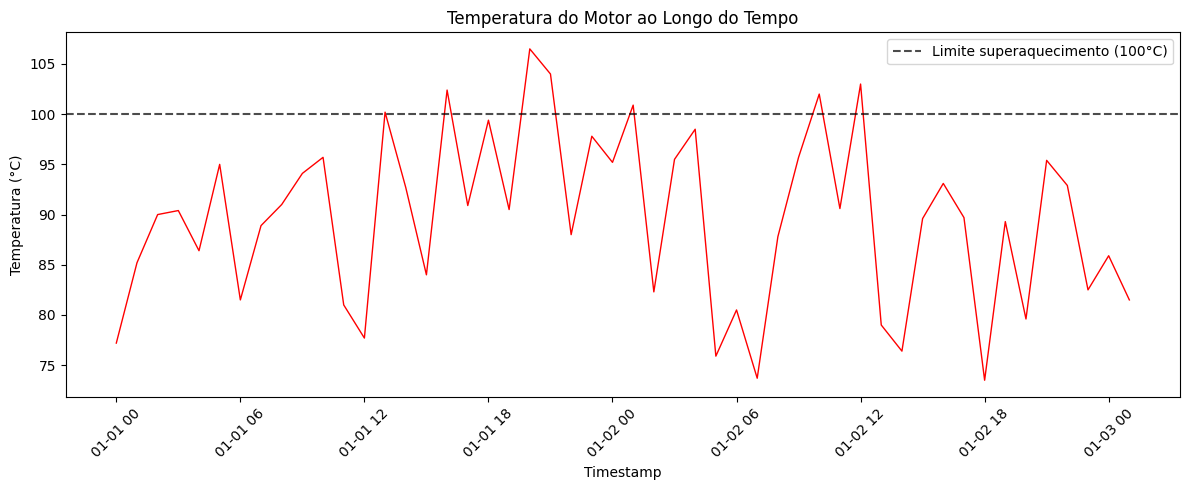

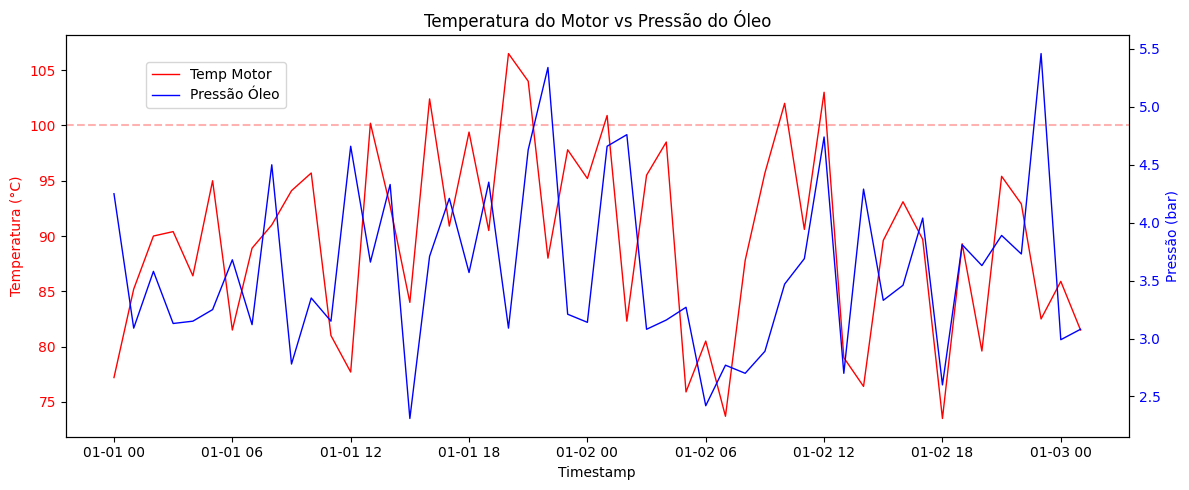

In [64]:
# Exercício 10 — Resolução

# 1. Gráfico de linha simples (50 primeiras leituras)
plt.figure(figsize=(12, 5))
plt.plot(df['timestamp'][:50], df['temp_motor_c'][:50], 'r-', linewidth=1)
plt.axhline(y=100, color='k', linestyle='--', alpha=0.7, label='Limite superaquecimento (100°C)')
plt.title('Temperatura do Motor ao Longo do Tempo')
plt.xlabel('Timestamp')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Eixos Y duplos
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(df['timestamp'][:50], df['temp_motor_c'][:50], 'r-', label='Temp Motor', linewidth=1)
ax1.set_xlabel('Timestamp')
ax1.set_ylabel('Temperatura (°C)', color='r')
ax1.tick_params(axis='y', labelcolor='r')
ax1.axhline(y=100, color='r', linestyle='--', alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(df['timestamp'][:50], df['pressao_oleo_bar'][:50], 'b-', label='Pressão Óleo', linewidth=1)
ax2.set_ylabel('Pressão (bar)', color='b')
ax2.tick_params(axis='y', labelcolor='b')

plt.title('Temperatura do Motor vs Pressão do Óleo')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Exercício 11 — Histogramas e distribuições


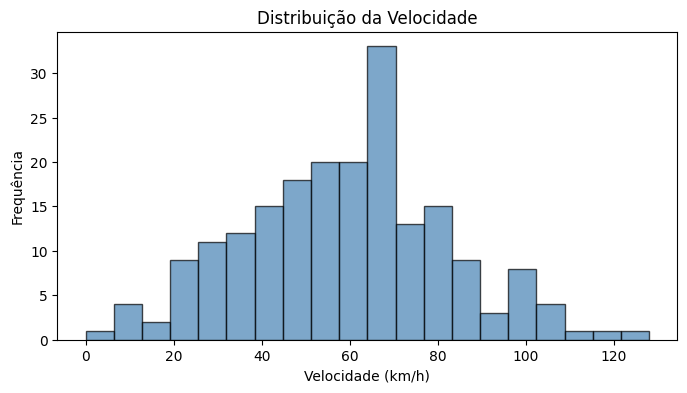

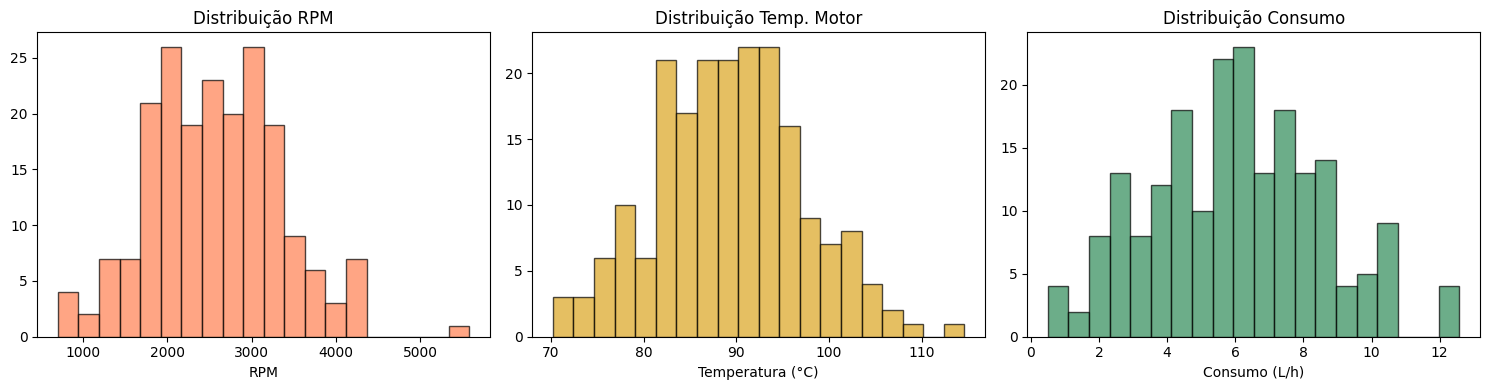

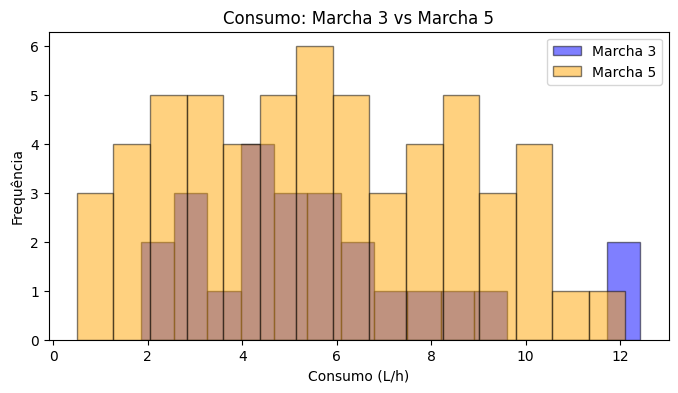

In [65]:
# Exercício 11 — Resolução

# 1. Histograma de velocidade
plt.figure(figsize=(8, 4))
plt.hist(df['velocidade_kmh'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
plt.title('Distribuição da Velocidade')
plt.xlabel('Velocidade (km/h)')
plt.ylabel('Frequência')
plt.show()

# 2. Subplots 1x3
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['rpm'], bins=20, edgecolor='black', alpha=0.7, color='coral')
axes[0].set_title('Distribuição RPM')
axes[0].set_xlabel('RPM')

axes[1].hist(df['temp_motor_c'], bins=20, edgecolor='black', alpha=0.7, color='goldenrod')
axes[1].set_title('Distribuição Temp. Motor')
axes[1].set_xlabel('Temperatura (°C)')

axes[2].hist(df['consumo_instantaneo_lh'], bins=20, edgecolor='black', alpha=0.7, color='seagreen')
axes[2].set_title('Distribuição Consumo')
axes[2].set_xlabel('Consumo (L/h)')

plt.tight_layout()
plt.show()

# 3. Histogramas sobrepostos marcha 3 vs 5
plt.figure(figsize=(8, 4))
plt.hist(df[df['marcha'] == 3]['consumo_instantaneo_lh'], bins=15, alpha=0.5, color='blue', label='Marcha 3', edgecolor='black')
plt.hist(df[df['marcha'] == 5]['consumo_instantaneo_lh'], bins=15, alpha=0.5, color='orange', label='Marcha 5', edgecolor='black')
plt.title('Consumo: Marcha 3 vs Marcha 5')
plt.xlabel('Consumo (L/h)')
plt.ylabel('Frequência')
plt.legend()
plt.show()


## Exercício 12 — Gráfico de dispersão (scatter plot)


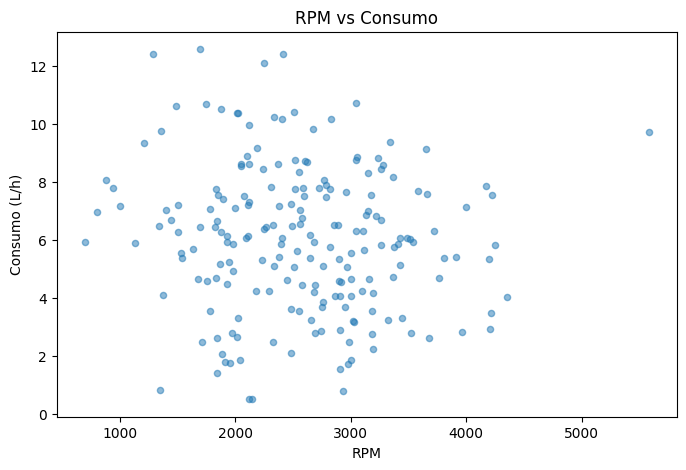

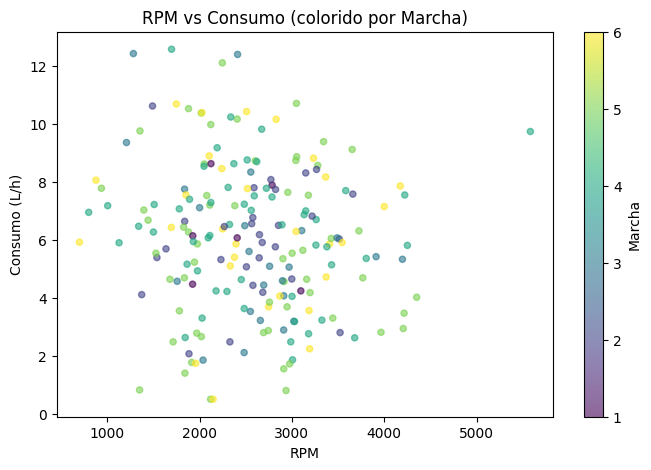

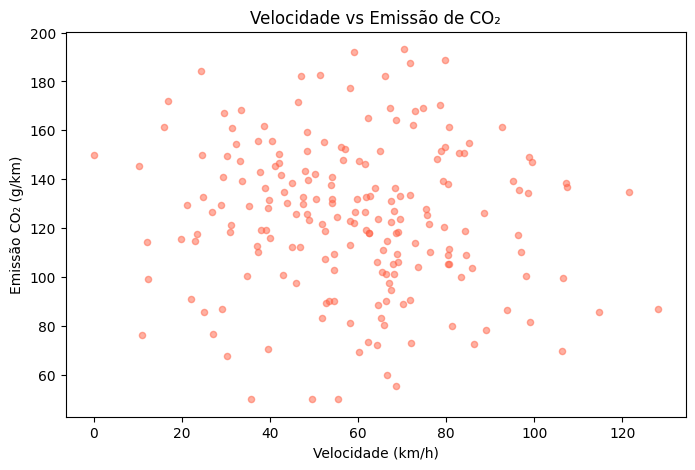

Os dados são simulados com distribuições independentes,
então não devemos ver uma correlação forte neste caso.


In [66]:
# Exercício 12 — Resolução

# 1. Scatter simples
plt.figure(figsize=(8, 5))
plt.scatter(df['rpm'], df['consumo_instantaneo_lh'], alpha=0.5, s=20)
plt.title('RPM vs Consumo')
plt.xlabel('RPM')
plt.ylabel('Consumo (L/h)')
plt.show()

# 2. Scatter colorido por marcha
plt.figure(figsize=(8, 5))
scatter = plt.scatter(df['rpm'], df['consumo_instantaneo_lh'],
                      c=df['marcha'], cmap='viridis', alpha=0.6, s=20)
plt.colorbar(scatter, label='Marcha')
plt.title('RPM vs Consumo (colorido por Marcha)')
plt.xlabel('RPM')
plt.ylabel('Consumo (L/h)')
plt.show()

# 3. Velocidade vs Emissão CO2
plt.figure(figsize=(8, 5))
plt.scatter(df['velocidade_kmh'], df['nivel_emissao_co2_gkm'], alpha=0.5, s=20, color='tomato')
plt.title('Velocidade vs Emissão de CO₂')
plt.xlabel('Velocidade (km/h)')
plt.ylabel('Emissão CO₂ (g/km)')
plt.show()
print("Os dados são simulados com distribuições independentes,")
print("então não devemos ver uma correlação forte neste caso.")


## Exercício 13 — Box plots para análise por grupos


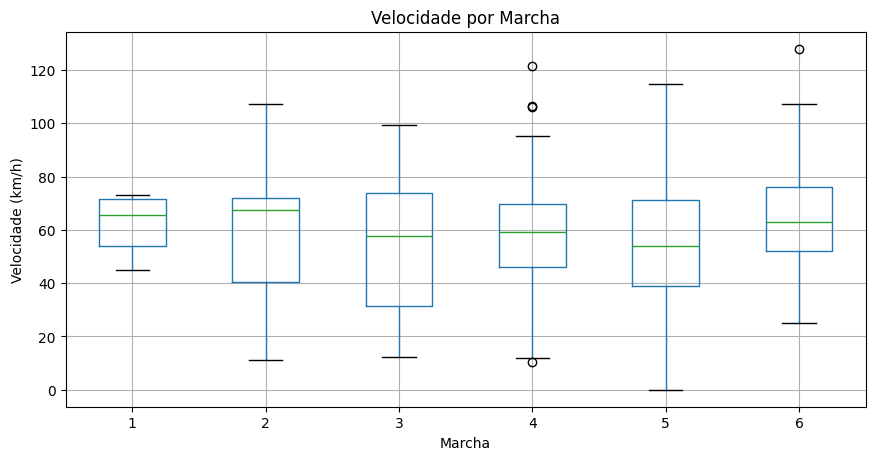

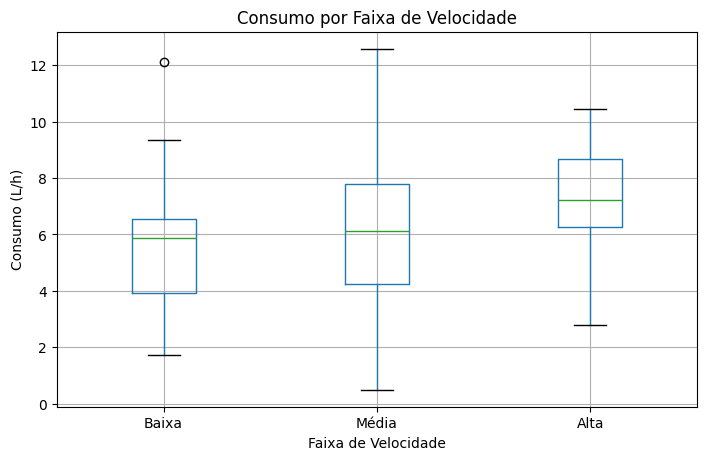

Observação: Como os dados são gerados aleatoriamente (independentes),
a variabilidade por marcha é similar. Em dados reais, marchas mais baixas
teriam menor range de velocidade e vice-versa.


In [67]:
# Exercício 13 — Resolução

# 1. Boxplot com Matplotlib
df.boxplot(column='velocidade_kmh', by='marcha', figsize=(10, 5))
plt.title('Velocidade por Marcha')
plt.suptitle('')
plt.ylabel('Velocidade (km/h)')
plt.xlabel('Marcha')
plt.show()

# 2. Boxplot com Plotly
fig = px.box(df, x='marcha', y='velocidade_kmh',
             title='Velocidade por Marcha (Plotly)',
             labels={'marcha': 'Marcha', 'velocidade_kmh': 'Velocidade (km/h)'})
fig.show()

# 3. Consumo por faixa de velocidade
df.boxplot(column='consumo_instantaneo_lh', by='faixa_velocidade', figsize=(8, 5))
plt.title('Consumo por Faixa de Velocidade')
plt.suptitle('')
plt.ylabel('Consumo (L/h)')
plt.xlabel('Faixa de Velocidade')
plt.show()

# 4. Interpretação
print("Observação: Como os dados são gerados aleatoriamente (independentes),")
print("a variabilidade por marcha é similar. Em dados reais, marchas mais baixas")
print("teriam menor range de velocidade e vice-versa.")


## Exercício 14 — Gráficos de barras


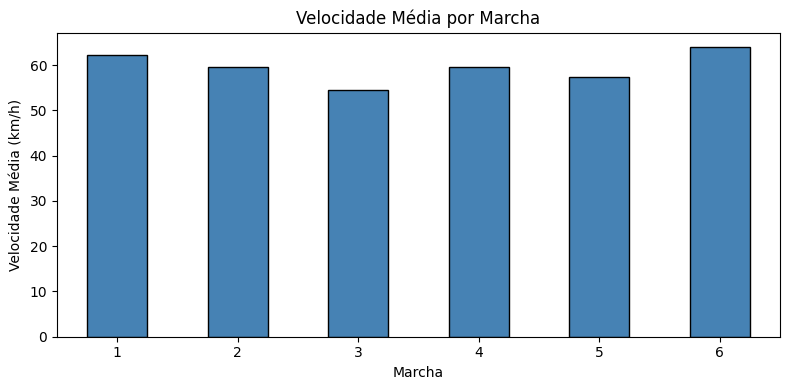

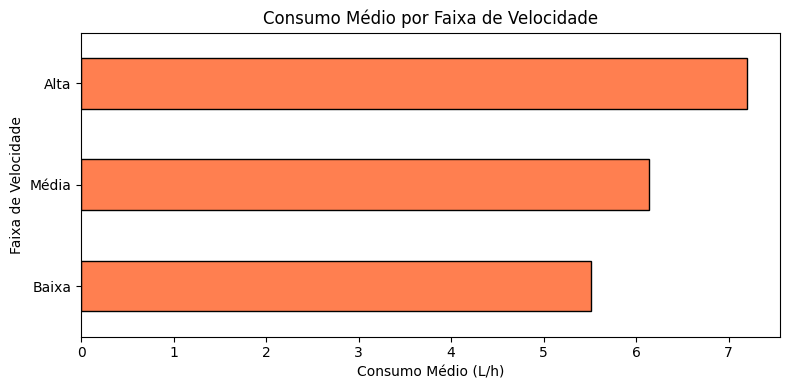

In [68]:
# Exercício 14 — Resolução

# 1. Velocidade média por marcha
vel_media = df.groupby('marcha')['velocidade_kmh'].mean()
plt.figure(figsize=(8, 4))
vel_media.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Velocidade Média por Marcha')
plt.xlabel('Marcha')
plt.ylabel('Velocidade Média (km/h)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 2. Consumo médio por faixa de velocidade (barras horizontais)
consumo_faixa = df.groupby('faixa_velocidade', observed=True)['consumo_instantaneo_lh'].mean()
plt.figure(figsize=(8, 4))
consumo_faixa.plot(kind='barh', color='coral', edgecolor='black')
plt.title('Consumo Médio por Faixa de Velocidade')
plt.xlabel('Consumo Médio (L/h)')
plt.ylabel('Faixa de Velocidade')
plt.tight_layout()
plt.show()

# 3. Plotly - barras agrupadas RPM e Consumo por marcha
resumo = df.groupby('marcha')[['rpm', 'consumo_instantaneo_lh']].mean().reset_index()
fig = go.Figure()
fig.add_trace(go.Bar(name='RPM Médio', x=resumo['marcha'], y=resumo['rpm']))
fig.add_trace(go.Bar(name='Consumo Médio (L/h)', x=resumo['marcha'], y=resumo['consumo_instantaneo_lh']))
fig.update_layout(barmode='group', title='RPM e Consumo Médio por Marcha',
                  xaxis_title='Marcha', yaxis_title='Valor')
fig.show()


## Exercício 15 — Heatmap de correlação


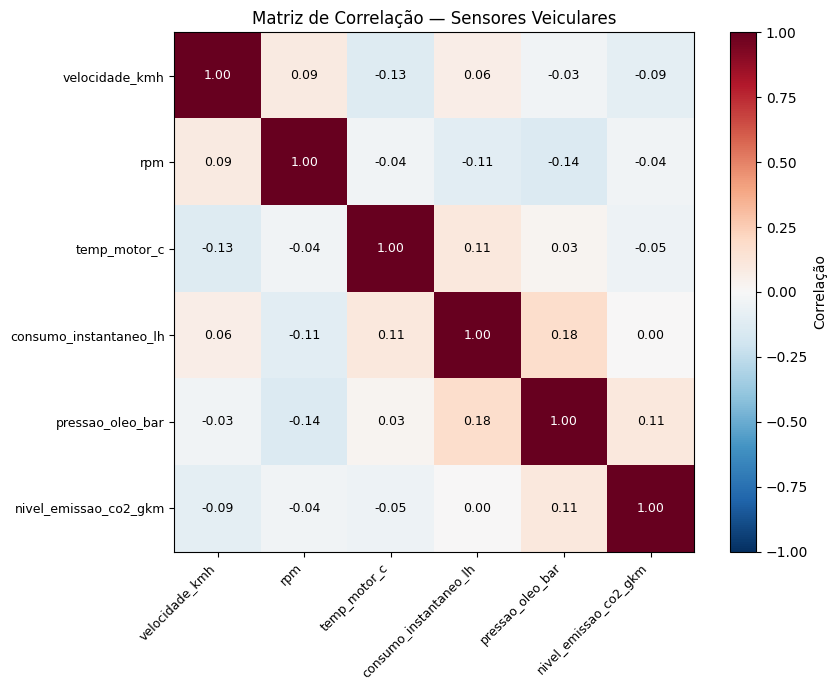

Correlação mais forte: consumo_instantaneo_lh vs pressao_oleo_bar = 0.175


In [69]:
# Exercício 15 — Resolução
cols_num = ['velocidade_kmh', 'rpm', 'temp_motor_c',
            'consumo_instantaneo_lh', 'pressao_oleo_bar', 'nivel_emissao_co2_gkm']
corr = df[cols_num].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(cols_num)))
ax.set_xticklabels(cols_num, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(cols_num)))
ax.set_yticklabels(cols_num, fontsize=9)
plt.colorbar(im, label='Correlação')

for i in range(len(cols_num)):
    for j in range(len(cols_num)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9,
                color='white' if abs(corr.iloc[i, j]) > 0.5 else 'black')

plt.title('Matriz de Correlação — Sensores Veiculares')
plt.tight_layout()
plt.show()

# Identificar correlação mais forte (fora da diagonal)
corr_abs = corr.abs()
np.fill_diagonal(corr_abs.values, 0)
max_corr = corr_abs.max().max()
idx = np.where(corr_abs.values == max_corr)
print(f"Correlação mais forte: {cols_num[idx[0][0]]} vs {cols_num[idx[1][0]]} = {corr.iloc[idx[0][0], idx[1][0]]:.3f}")


## Exercício 16 — Visualizações interativas com Plotly


In [70]:
# Exercício 16 — Resolução

# 1. Scatter interativo RPM vs Consumo colorido por marcha
fig = px.scatter(df, x='rpm', y='consumo_instantaneo_lh', color='marcha',
                 title='RPM vs Consumo (por Marcha)',
                 labels={'rpm': 'RPM', 'consumo_instantaneo_lh': 'Consumo (L/h)', 'marcha': 'Marcha'},
                 opacity=0.6)
fig.show()

# 2. Linha interativa da temperatura ao longo do tempo
fig = px.line(df, x='timestamp', y='temp_motor_c',
              title='Temperatura do Motor ao Longo do Tempo',
              labels={'timestamp': 'Tempo', 'temp_motor_c': 'Temperatura (°C)'})
fig.add_hline(y=100, line_dash='dash', line_color='red', annotation_text='Limite 100°C')
fig.show()

# 3. Scatter matrix
fig = px.scatter_matrix(df,
    dimensions=['rpm', 'velocidade_kmh', 'consumo_instantaneo_lh', 'temp_motor_c'],
    color='marcha',
    title='Matriz de Dispersão — Variáveis do Motor',
    opacity=0.5)
fig.update_traces(diagonal_visible=True)
fig.update_layout(height=700)
fig.show()

# 4. Histograma facetado
fig = px.histogram(df, x='nivel_emissao_co2_gkm', facet_col='faixa_velocidade',
                   title='Emissão de CO₂ por Faixa de Velocidade',
                   labels={'nivel_emissao_co2_gkm': 'Emissão CO₂ (g/km)'},
                   nbins=20, color='faixa_velocidade')
fig.show()


---
# Parte 4 — Exercícios Integrados (Desafios)


## Exercício 17 — Análise de mapa de calibração de motor


In [71]:
# Simulando dados de um mapa de calibração
rpm_vals = np.arange(1000, 7000, 500)
carga_vals = np.arange(10, 110, 10)

rpm_grid, carga_grid = np.meshgrid(rpm_vals, carga_vals)
avanco_ignicao = 35 - 0.003 * rpm_grid - 0.15 * carga_grid + 0.000002 * rpm_grid * carga_grid
avanco_ignicao += np.random.normal(0, 0.5, avanco_ignicao.shape)

df_mapa = pd.DataFrame({
    'rpm': rpm_grid.flatten(),
    'carga_pct': carga_grid.flatten(),
    'avanco_ignicao_graus': avanco_ignicao.flatten().round(1)
})
print(df_mapa.head(10))
print(f"\nShape: {df_mapa.shape}")


    rpm  carga_pct  avanco_ignicao_graus
0  1000         10                  30.2
1  1500         10                  29.4
2  2000         10                  28.5
3  2500         10                  24.6
4  3000         10                  24.4
5  3500         10                  23.2
6  4000         10                  21.6
7  4500         10                  19.9
8  5000         10                  17.9
9  5500         10                  16.6

Shape: (120, 3)


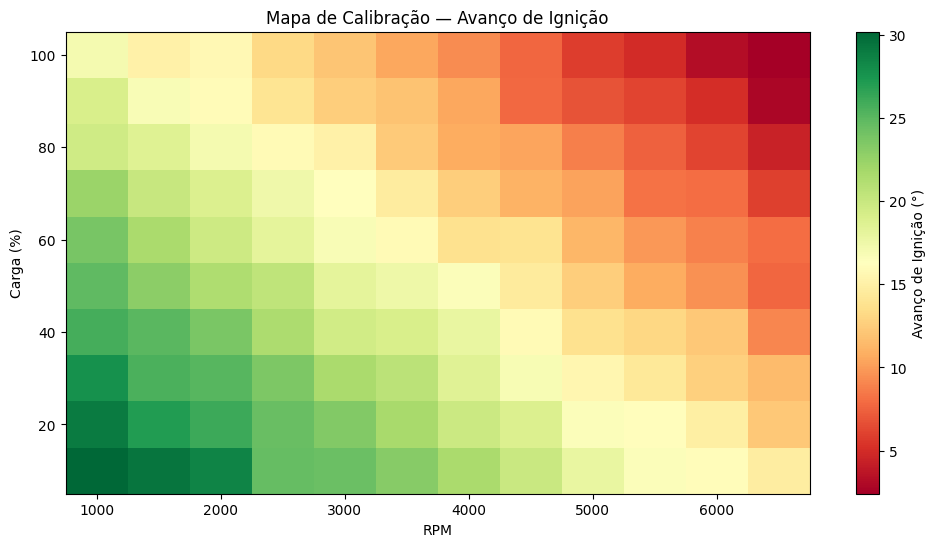

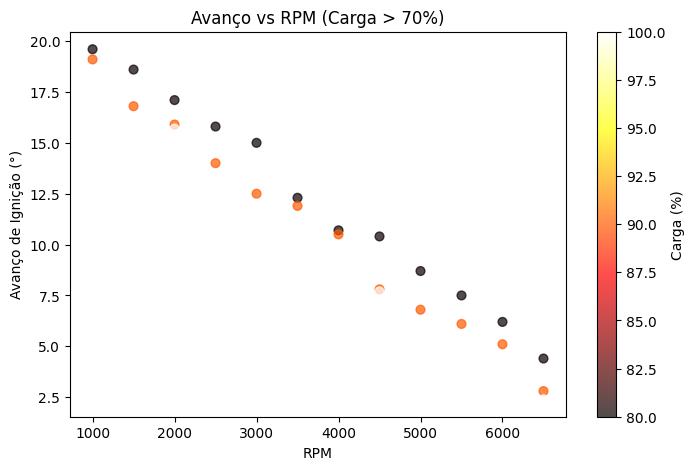

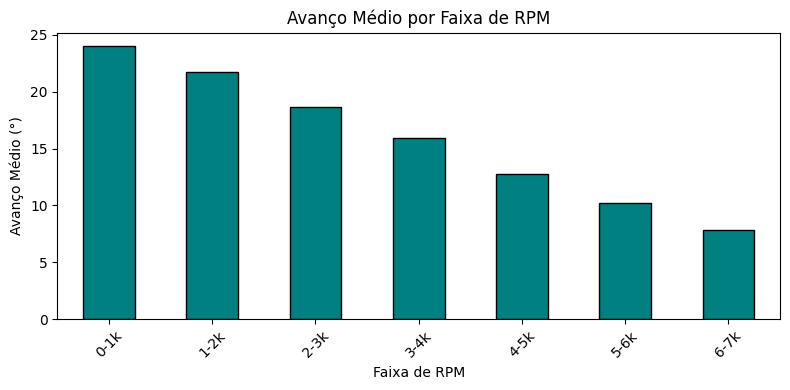

Menor avanço: 2.4°
  RPM: 6500
  Carga: 100%


In [72]:
# Exercício 17 — Resolução

# 1. Heatmap do mapa de avanço de ignição
pivot = df_mapa.pivot_table(index='carga_pct', columns='rpm', values='avanco_ignicao_graus')

plt.figure(figsize=(12, 6))
plt.pcolormesh(pivot.columns, pivot.index, pivot.values, cmap='RdYlGn', shading='auto')
plt.colorbar(label='Avanço de Ignição (°)')
plt.xlabel('RPM')
plt.ylabel('Carga (%)')
plt.title('Mapa de Calibração — Avanço de Ignição')
plt.show()

# Versão Plotly
fig = px.imshow(pivot, origin='lower', color_continuous_scale='RdYlGn',
                labels={'x': 'RPM', 'y': 'Carga (%)', 'color': 'Avanço (°)'},
                title='Mapa de Calibração — Avanço de Ignição (Plotly)')
fig.show()

# 2. Carga > 70%, avanço vs RPM
alta_carga = df_mapa[df_mapa['carga_pct'] > 70]
plt.figure(figsize=(8, 5))
plt.scatter(alta_carga['rpm'], alta_carga['avanco_ignicao_graus'],
            c=alta_carga['carga_pct'], cmap='hot', s=40, alpha=0.7)
plt.colorbar(label='Carga (%)')
plt.title('Avanço vs RPM (Carga > 70%)')
plt.xlabel('RPM')
plt.ylabel('Avanço de Ignição (°)')
plt.show()

# 3. Avanço médio por faixa de RPM (a cada 1000)
df_mapa['faixa_rpm'] = pd.cut(df_mapa['rpm'], bins=range(0, 8000, 1000),
                               labels=[f'{i}-{i+1}k' for i in range(0, 7)])
avanco_por_faixa = df_mapa.groupby('faixa_rpm', observed=True)['avanco_ignicao_graus'].mean()

plt.figure(figsize=(8, 4))
avanco_por_faixa.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Avanço Médio por Faixa de RPM')
plt.xlabel('Faixa de RPM')
plt.ylabel('Avanço Médio (°)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 4. Combinação com menor avanço
idx_min = df_mapa['avanco_ignicao_graus'].idxmin()
print(f"Menor avanço: {df_mapa.loc[idx_min, 'avanco_ignicao_graus']}°")
print(f"  RPM: {df_mapa.loc[idx_min, 'rpm']}")
print(f"  Carga: {df_mapa.loc[idx_min, 'carga_pct']}%")


## Exercício 18 — Dashboard de monitoramento de teste


In [ ]:
# Exercício 18 — Resolução
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Dashboard — Teste de Durabilidade', fontsize=16, fontweight='bold')

# Superior esquerdo: Linha velocidade
axes[0, 0].plot(df['timestamp'][:100], df['velocidade_kmh'][:100], 'b-', linewidth=0.8)
axes[0, 0].set_title('Velocidade ao Longo do Tempo')
axes[0, 0].set_ylabel('Velocidade (km/h)')
axes[0, 0].tick_params(axis='x', rotation=45)

# Superior direito: Histograma RPM
axes[0, 1].hist(df['rpm'], bins=25, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].axvline(df['rpm'].mean(), color='black', linestyle='--', label=f"Média: {df['rpm'].mean():.0f}")
axes[0, 1].set_title('Distribuição de RPM')
axes[0, 1].set_xlabel('RPM')
axes[0, 1].legend()

# Inferior esquerdo: Scatter RPM vs Consumo
axes[1, 0].scatter(df['rpm'], df['consumo_instantaneo_lh'], alpha=0.4, s=15, color='teal')
axes[1, 0].set_title('RPM vs Consumo')
axes[1, 0].set_xlabel('RPM')
axes[1, 0].set_ylabel('Consumo (L/h)')

# Inferior direito: Boxplot consumo por marcha
dados_box = [df[df['marcha'] == m]['consumo_instantaneo_lh'].dropna().values for m in sorted(df['marcha'].unique())]
axes[1, 1].boxplot(dados_box, labels=sorted(df['marcha'].unique()))
axes[1, 1].set_title('Consumo por Marcha')
axes[1, 1].set_xlabel('Marcha')
axes[1, 1].set_ylabel('Consumo (L/h)')

plt.tight_layout()
plt.show()


## Exercício 19 — Análise temporal com resample


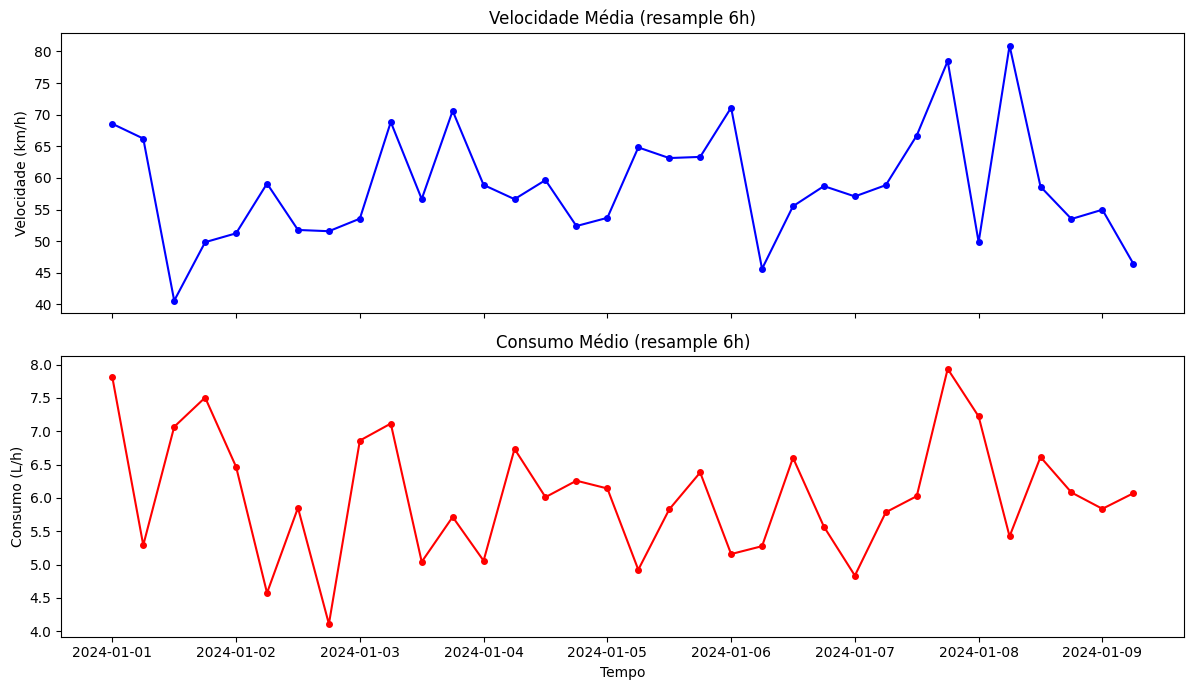

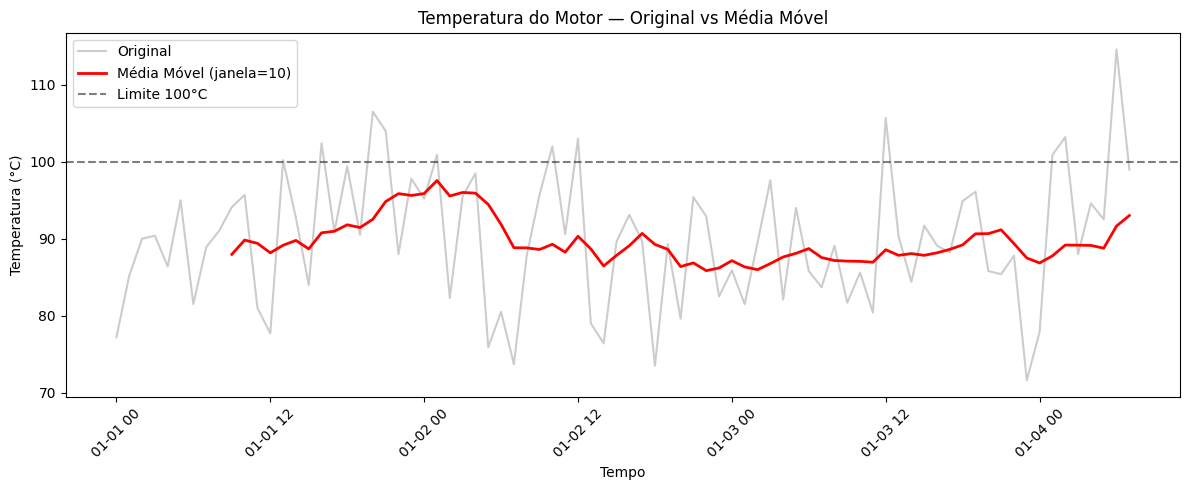

In [73]:
# Exercício 19 — Resolução

# 1 e 2. Resample para 6 horas
df_ts = df.set_index('timestamp')
df_6h = df_ts.resample('6h').mean(numeric_only=True)

# 3. Plot dos dados resampleados
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(df_6h.index, df_6h['velocidade_kmh'], 'b-o', markersize=4)
axes[0].set_title('Velocidade Média (resample 6h)')
axes[0].set_ylabel('Velocidade (km/h)')

axes[1].plot(df_6h.index, df_6h['consumo_instantaneo_lh'], 'r-o', markersize=4)
axes[1].set_title('Consumo Médio (resample 6h)')
axes[1].set_ylabel('Consumo (L/h)')
axes[1].set_xlabel('Tempo')
plt.tight_layout()
plt.show()

# 4. Média móvel de temperatura
df['temp_rolling_10'] = df['temp_motor_c'].rolling(window=10).mean()

plt.figure(figsize=(12, 5))
plt.plot(df['timestamp'][:80], df['temp_motor_c'][:80], alpha=0.4, label='Original', color='gray')
plt.plot(df['timestamp'][:80], df['temp_rolling_10'][:80], label='Média Móvel (janela=10)', color='red', linewidth=2)
plt.axhline(y=100, color='black', linestyle='--', alpha=0.5, label='Limite 100°C')
plt.title('Temperatura do Motor — Original vs Média Móvel')
plt.xlabel('Tempo')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Exercício 20 — Desafio Final: Relatório de análise completo


In [74]:
# Exercício 20 — Resolução

# === 1. RESUMO ESTATÍSTICO ===
print("="*60)
print("1. RESUMO ESTATÍSTICO")
print("="*60)
print(f"\nDataset: {df.shape[0]} registros, {df.shape[1]} colunas")
print(f"Período: {df['timestamp'].min()} a {df['timestamp'].max()}")
print("\nEstatísticas descritivas:")
print(df.describe().round(2))


1. RESUMO ESTATÍSTICO

Dataset: 200 registros, 11 colunas
Período: 2024-01-01 00:00:00 a 2024-01-09 07:00:00

Estatísticas descritivas:
                           timestamp  velocidade_kmh      rpm  temp_motor_c  \
count                            200          200.00   200.00        200.00   
mean   2024-01-05 03:30:00.000000256           59.01  2572.16         89.31   
min              2024-01-01 00:00:00            0.00   700.00         70.20   
25%              2024-01-03 01:45:00           42.32  2014.50         83.68   
50%              2024-01-05 03:30:00           59.90  2562.50         89.40   
75%              2024-01-07 05:15:00           72.50  3049.75         94.60   
max              2024-01-09 07:00:00          128.00  5582.00        114.60   
std                              NaN           23.20   778.11          7.95   

       consumo_instantaneo_lh  pressao_oleo_bar  nivel_emissao_co2_gkm  \
count                  200.00            200.00                 200.00   
mean

In [75]:
# === 2. DETECÇÃO DE ANOMALIAS ===
print("="*60)
print("2. DETECÇÃO DE ANOMALIAS")
print("="*60)

superaquecimento = df[df['temp_motor_c'] > 110]
pressao_baixa = df[df['pressao_oleo_bar'] < 1.5]

print(f"\nRegistros com superaquecimento (temp > 110°C): {len(superaquecimento)}")
if len(superaquecimento) > 0:
    print(superaquecimento[['timestamp', 'temp_motor_c', 'rpm', 'velocidade_kmh']].head())

print(f"\nRegistros com pressão de óleo baixa (< 1.5 bar): {len(pressao_baixa)}")
if len(pressao_baixa) > 0:
    print(pressao_baixa[['timestamp', 'pressao_oleo_bar', 'rpm']].head())

print(f"\nTotal de registros anômalos: {len(superaquecimento) + len(pressao_baixa)}")


2. DETECÇÃO DE ANOMALIAS

Registros com superaquecimento (temp > 110°C): 1
             timestamp  temp_motor_c   rpm  velocidade_kmh
78 2024-01-04 06:00:00         114.6  2555            62.3

Registros com pressão de óleo baixa (< 1.5 bar): 0

Total de registros anômalos: 1


3. ANÁLISE POR MARCHA
        Vel. Média (km/h)  Consumo Médio (L/h)  RPM Médio
marcha                                                   
1                   62.15                 6.24    2377.83
2                   59.57                 5.99    2575.00
3                   54.47                 5.72    2611.92
4                   59.54                 6.31    2569.44
5                   57.33                 5.68    2574.97
6                   63.92                 6.49    2576.07


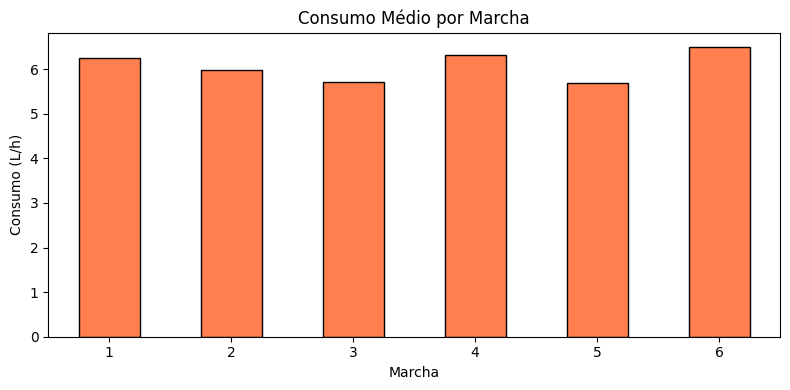

In [76]:
# === 3. ANÁLISE POR MARCHA ===
print("="*60)
print("3. ANÁLISE POR MARCHA")
print("="*60)

resumo_marcha = df.groupby('marcha').agg({
    'velocidade_kmh': 'mean',
    'consumo_instantaneo_lh': 'mean',
    'rpm': 'mean'
}).round(2)
resumo_marcha.columns = ['Vel. Média (km/h)', 'Consumo Médio (L/h)', 'RPM Médio']
print(resumo_marcha)

# Gráfico de barras
fig, ax = plt.subplots(figsize=(8, 4))
resumo_marcha['Consumo Médio (L/h)'].plot(kind='bar', color='coral', edgecolor='black', ax=ax)
ax.set_title('Consumo Médio por Marcha')
ax.set_xlabel('Marcha')
ax.set_ylabel('Consumo (L/h)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


4. CORRELAÇÕES


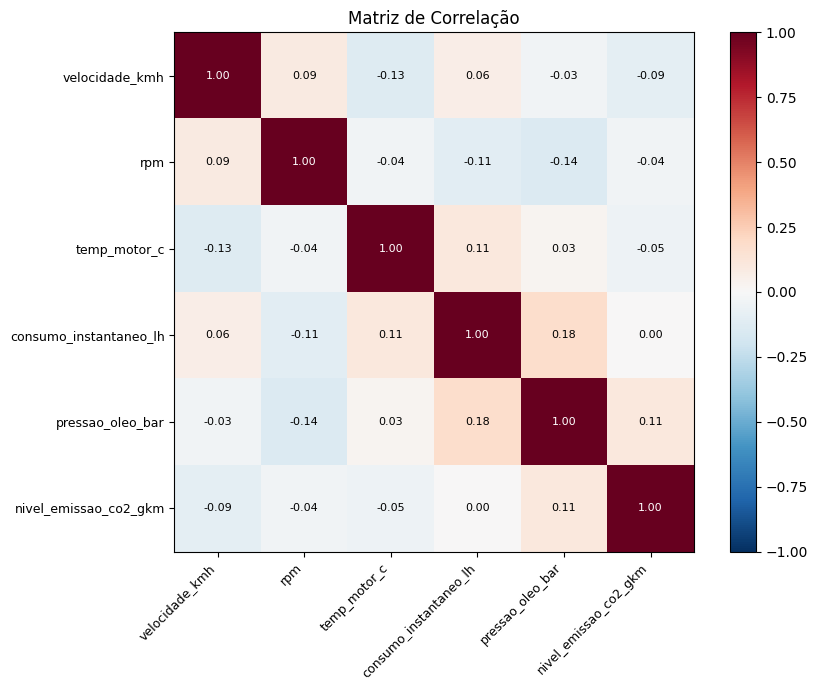


Correlação mais forte: consumo_instantaneo_lh vs pressao_oleo_bar = 0.175


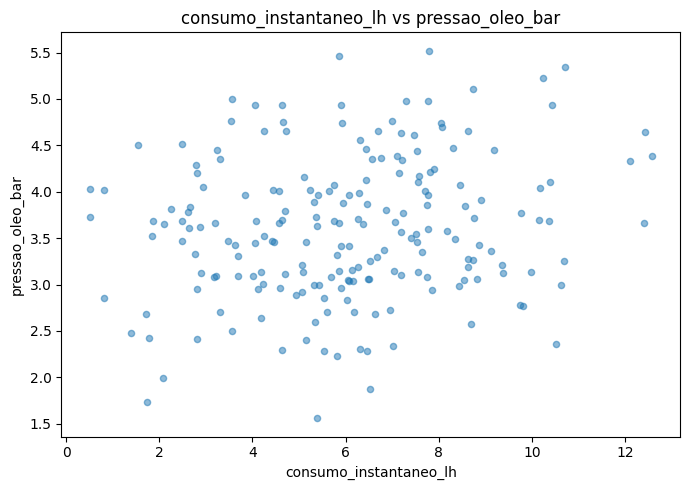

In [77]:
# === 4. CORRELAÇÕES ===
print("="*60)
print("4. CORRELAÇÕES")
print("="*60)

cols_num = ['velocidade_kmh', 'rpm', 'temp_motor_c',
            'consumo_instantaneo_lh', 'pressao_oleo_bar', 'nivel_emissao_co2_gkm']
corr = df[cols_num].corr()

# Heatmap
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(cols_num)))
ax.set_xticklabels(cols_num, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(cols_num)))
ax.set_yticklabels(cols_num, fontsize=9)
plt.colorbar(im)
for i in range(len(cols_num)):
    for j in range(len(cols_num)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8,
                color='white' if abs(corr.iloc[i, j]) > 0.5 else 'black')
plt.title('Matriz de Correlação')
plt.tight_layout()
plt.show()

# Scatter da correlação mais forte
corr_abs = corr.abs()
np.fill_diagonal(corr_abs.values, 0)
idx = np.unravel_index(corr_abs.values.argmax(), corr_abs.shape)
var1, var2 = cols_num[idx[0]], cols_num[idx[1]]
print(f"\nCorrelação mais forte: {var1} vs {var2} = {corr.iloc[idx[0], idx[1]]:.3f}")

plt.figure(figsize=(7, 5))
plt.scatter(df[var1], df[var2], alpha=0.5, s=20)
plt.title(f'{var1} vs {var2}')
plt.xlabel(var1)
plt.ylabel(var2)
plt.tight_layout()
plt.show()


5. SÉRIE TEMPORAL


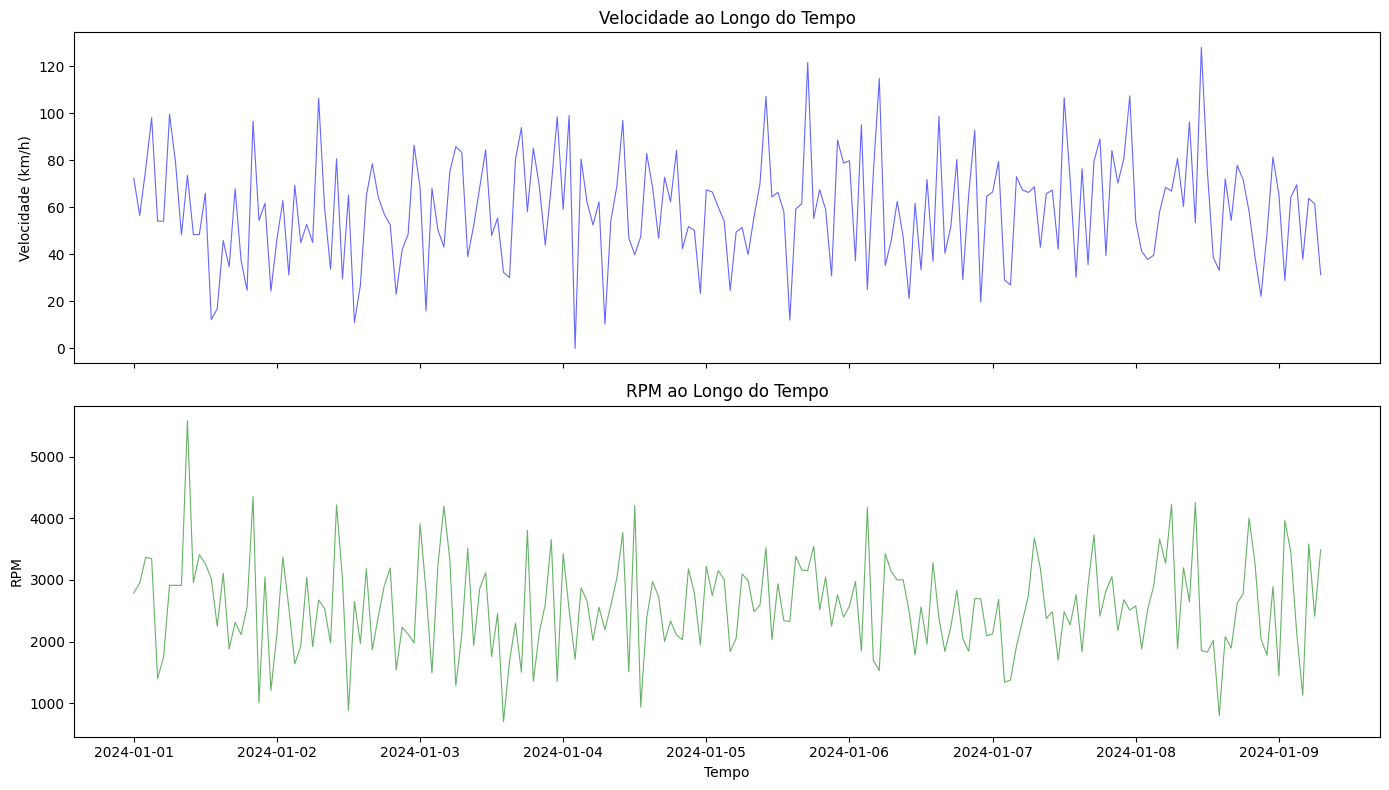

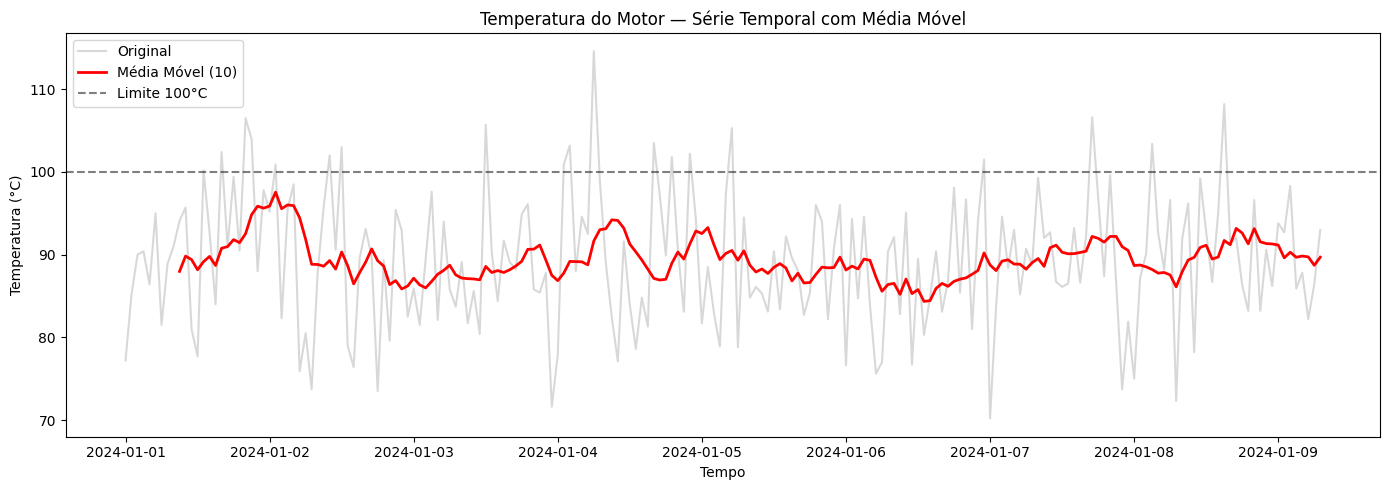

In [78]:
# === 5. SÉRIE TEMPORAL ===
print("="*60)
print("5. SÉRIE TEMPORAL")
print("="*60)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df['timestamp'], df['velocidade_kmh'], alpha=0.6, linewidth=0.8, color='blue')
axes[0].set_title('Velocidade ao Longo do Tempo')
axes[0].set_ylabel('Velocidade (km/h)')

axes[1].plot(df['timestamp'], df['rpm'], alpha=0.6, linewidth=0.8, color='green')
axes[1].set_title('RPM ao Longo do Tempo')
axes[1].set_ylabel('RPM')
axes[1].set_xlabel('Tempo')
plt.tight_layout()
plt.show()

# Média móvel temperatura
df['temp_rolling'] = df['temp_motor_c'].rolling(window=10).mean()
plt.figure(figsize=(14, 5))
plt.plot(df['timestamp'], df['temp_motor_c'], alpha=0.3, label='Original', color='gray')
plt.plot(df['timestamp'], df['temp_rolling'], label='Média Móvel (10)', color='red', linewidth=2)
plt.axhline(y=100, color='black', linestyle='--', alpha=0.5, label='Limite 100°C')
plt.title('Temperatura do Motor — Série Temporal com Média Móvel')
plt.xlabel('Tempo')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.tight_layout()
plt.show()


### 6. Conclusão

Mesmo com dados simulados, podemos observar:

- **Distribuições**: As variáveis seguem distribuições aproximadamente normais (esperado, dado o gerador `np.random.normal`).
- **Anomalias**: Poucos registros ultrapassam os limites críticos de temperatura ou pressão, o que seria diferente em dados reais de testes extremos.
- **Correlações**: Em dados simulados independentemente, as correlações são fracas. Em dados reais, esperaríamos correlações fortes entre RPM-consumo, velocidade-marcha, carga-temperatura etc.
- **Marchas**: A ausência de correlação marcha-velocidade evidencia a natureza aleatória dos dados. Em dados reais, cada marcha teria uma faixa de velocidade bem definida.
- **Séries temporais**: A média móvel suaviza as flutuações, facilitando a identificação de tendências — técnica muito útil em análise de dados de calibração para filtrar ruído de sensores.


---
# Resumo e Referências

## Referências:
- [Pandas Documentation](https://pandas.pydata.org/docs/)
- [Pandas Cheat Sheet](https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf)
- [Matplotlib Gallery](https://matplotlib.org/stable/gallery/)
- [Plotly Express](https://plotly.com/python/plotly-express/)
- [Python Data Science Handbook](https://jakevdp.github.io/PythonDataScienceHandbook/)


# Conteúdo adicional sobre `loc` e `iloc`

In [80]:
df = df.set_index('timestamp')

In [81]:
df

,velocidade_kmh,rpm,temp_motor_c,consumo_instantaneo_lh,pressao_oleo_bar,nivel_emissao_co2_gkm,marcha,eficiencia,faixa_velocidade,temp_rolling_10,temp_rolling
timestamp,,,,,,,,,,,
2024-01-01 00:00:00,72.4,2786,77.2,7.89,4.25,162.0,1,9.18,Média,NaN,NaN
2024-01-01 01:00:00,56.5,2948,85.2,3.69,3.09,147.7,5,15.31,Média,NaN,NaN
2024-01-01 02:00:00,76.2,3366,90.0,8.17,3.58,121.8,6,9.33,Média,NaN,NaN
2024-01-01 03:00:00,98.1,3343,90.4,9.39,3.13,100.6,5,10.45,Média,NaN,NaN
2024-01-01 04:00:00,54.1,1397,86.4,7.03,3.15,140.9,5,7.70,Média,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2024-01-09 03:00:00,69.6,2124,85.9,8.63,3.28,133.2,1,8.06,Média,89.68,89.68
2024-01-09 04:00:00,37.9,1129,87.8,5.90,4.94,119.4,4,6.42,Baixa,89.83,89.83
2024-01-09 05:00:00,63.8,3583,82.2,7.70,4.01,136.6,4,8.29,Média,89.73,89.73


In [98]:
df.columns

Index(['velocidade_kmh', 'rpm', 'temp_motor_c', 'consumo_instantaneo_lh',
       'pressao_oleo_bar', 'nivel_emissao_co2_gkm', 'marcha', 'eficiencia',
       'faixa_velocidade', 'temp_rolling_10', 'temp_rolling'],
      dtype='object')

In [93]:
df.iloc[4:10, 0:3]

,velocidade_kmh,rpm,temp_motor_c
timestamp,,,
2024-01-01 04:00:00,54.1,1397,86.4
2024-01-01 05:00:00,54.1,1749,95.0
2024-01-01 06:00:00,99.5,2912,81.5
2024-01-01 07:00:00,79.2,2911,88.9
2024-01-01 08:00:00,48.3,2912,91.0
2024-01-01 09:00:00,73.6,5582,94.1


In [99]:
df.loc['2024-01-01 06:00:00':'2024-01-01 09:00:00', 'velocidade_kmh':'pressao_oleo_bar']

,velocidade_kmh,rpm,temp_motor_c,consumo_instantaneo_lh,pressao_oleo_bar
timestamp,,,,,
2024-01-01 06:00:00,99.5,2912,81.5,4.07,3.68
2024-01-01 07:00:00,79.2,2911,88.9,2.89,3.12
2024-01-01 08:00:00,48.3,2912,91.0,1.55,4.50
2024-01-01 09:00:00,73.6,5582,94.1,9.74,2.78
